# Project 21 - Volume Controller

**Task Family:** Hand landmarks + control logic  
**Preferred Stack:** MediaPipe Hand Landmarker  
**Dataset:** Kaggle LeapGestRec  
**Dataset Link:** https://www.kaggle.com/datasets/gti-upm/leapgestrecog  
**Goal:** Build a notebook-first, honest audit of thumb-index distance based volume control on real downloaded hand images.

## Project Overview

The original project maps the distance between the thumb tip and the index tip to system volume. That control logic is correct for hand-landmark driven interaction, and this notebook preserves that idea. Because LeapGestRec is an image dataset rather than a live webcam benchmark, the notebook does **not** pretend to measure real desktop volume control performance. Instead, it performs a real inference audit on downloaded gesture images and reports honest proxy outputs: pinch distance, virtual volume percentage, handedness, and gesture-level patterns.

## Environment Setup

Install only the packages required for dataset download, MediaPipe hand landmarks, data analysis, and plotting.

In [1]:
import importlib
import subprocess
import sys

def ensure_pkg(import_name, install_name=None):
    install_name = install_name or import_name
    try:
        importlib.import_module(import_name)
        print(f'✓ {install_name}')
    except ImportError:
        print(f'Installing {install_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', install_name])
        print(f'✓ {install_name}')

ensure_pkg('kagglehub')
ensure_pkg('mediapipe')
ensure_pkg('cv2', 'opencv-python')
ensure_pkg('numpy')
ensure_pkg('pandas')
ensure_pkg('matplotlib')
print('\n✓ All packages ready')

e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ kagglehub
✓ mediapipe
✓ opencv-python
✓ numpy
✓ pandas
✓ matplotlib

✓ All packages ready


## Imports and Configuration

Create project-local output and model folders and keep the run deterministic where possible.

In [2]:
import json
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
from IPython.display import display
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

SEED = 42
np.random.seed(SEED)

BASE_DIR = Path.home() / 'volume_controller_project'
OUTPUT_DIR = BASE_DIR / 'outputs'
MODEL_DIR = BASE_DIR / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.figsize'] = (14, 8)

print(f'Base directory: {BASE_DIR}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'Model directory: {MODEL_DIR}')

Base directory: C:\Users\ahmad\volume_controller_project
Output directory: C:\Users\ahmad\volume_controller_project\outputs
Model directory: C:\Users\ahmad\volume_controller_project\models


## Dataset Download and Verification

Download the real LeapGestRec dataset inside the notebook and verify discovered labels, participant folders, image counts, and the absence of an official train/validation/test split.

In [3]:
import kagglehub

kaggle_token_path = Path.home() / '.kaggle' / 'kaggle.json'
if not kaggle_token_path.exists():
    raise FileNotFoundError('Missing Kaggle credentials at ~/.kaggle/kaggle.json')

print('Downloading dataset with kagglehub.dataset_download(...) ...')
DATASET_DIR = Path(kagglehub.dataset_download('gti-upm/leapgestrecog'))
if not DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset path does not exist: {DATASET_DIR}')

image_paths = sorted(DATASET_DIR.rglob('*.jpg')) + sorted(DATASET_DIR.rglob('*.png')) + sorted(DATASET_DIR.rglob('*.jpeg'))
if not image_paths:
    raise RuntimeError(f'No images found under {DATASET_DIR}')

relative_parts = [image_path.relative_to(DATASET_DIR).parts for image_path in image_paths]
participant_ids = sorted({parts[0] for parts in relative_parts if len(parts) >= 3})
labels = [parts[-2] for parts in relative_parts if len(parts) >= 2]
label_counts = pd.Series(labels, dtype='string').value_counts().sort_index()
verification_df = pd.DataFrame({'label': label_counts.index, 'image_count': label_counts.values})

print(f'✓ Dataset root: {DATASET_DIR}')
print(f'✓ Participants found: {len(participant_ids)}')
print(f'✓ Labels found: {len(label_counts)}')
print(f'✓ Images found: {len(image_paths)}')
print('✓ Official split provided by source: none')
display(verification_df)

✓ Dataset root: C:\Users\ahmad\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1
✓ Participants found: 1
✓ Labels found: 10
✓ Images found: 40000
✓ Official split provided by source: none


,label,image_count
0,01_palm,4000
1,02_l,4000
2,03_fist,4000
3,04_fist_moved,4000
4,05_thumb,4000
5,06_index,4000
6,07_ok,4000
7,08_palm_moved,4000
8,09_c,4000
9,10_down,4000


## Hand Landmarker Bootstrap

MediaPipe Tasks requires a real `.task` model asset, so the notebook downloads it explicitly instead of relying on a nonexistent bundled default.

In [4]:
MODEL_URL = ('https://storage.googleapis.com/mediapipe-models/'
             'hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task')
MODEL_PATH = MODEL_DIR / 'hand_landmarker.task'

if not MODEL_PATH.exists():
    print(f'Downloading model asset to {MODEL_PATH} ...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=str(MODEL_PATH)),
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)
hand_detector = vision.HandLandmarker.create_from_options(options)
print(f'✓ Model asset ready: {MODEL_PATH.name}')
print('✓ MediaPipe Hand Landmarker initialized')

✓ Model asset ready: hand_landmarker.task
✓ MediaPipe Hand Landmarker initialized


## Volume Control Logic

The original interaction logic maps thumb-tip to index-tip distance into a volume percentage. This notebook keeps that mapping but labels it as a **virtual volume signal** because we are evaluating on still images, not actively changing the system audio level.

In [5]:
THUMB_TIP = 4
INDEX_TIP = 8
MIN_PINCH_DISTANCE = 0.02
MAX_PINCH_DISTANCE = 0.35

def compute_hand_box(hand_landmarks):
    xs = [landmark.x for landmark in hand_landmarks]
    ys = [landmark.y for landmark in hand_landmarks]
    bbox_width = float(max(xs) - min(xs))
    bbox_height = float(max(ys) - min(ys))
    hand_size = float((bbox_width ** 2 + bbox_height ** 2) ** 0.5)
    return bbox_width, bbox_height, hand_size

def pinch_distance(hand_landmarks):
    thumb = hand_landmarks[THUMB_TIP]
    index = hand_landmarks[INDEX_TIP]
    distance = float(np.hypot(thumb.x - index.x, thumb.y - index.y))
    return thumb, index, distance

def distance_to_volume_percent(distance):
    return float(np.interp(distance, [MIN_PINCH_DISTANCE, MAX_PINCH_DISTANCE], [0.0, 100.0]).clip(0.0, 100.0))

def annotate_volume_signal(image_bgr, hand_landmarks, handedness, volume_percent):
    annotated = image_bgr.copy()
    height, width = annotated.shape[:2]
    for landmark in hand_landmarks:
        x_px = int(landmark.x * width)
        y_px = int(landmark.y * height)
        cv2.circle(annotated, (x_px, y_px), 3, (0, 255, 0), -1)
    thumb = hand_landmarks[THUMB_TIP]
    index = hand_landmarks[INDEX_TIP]
    thumb_xy = (int(thumb.x * width), int(thumb.y * height))
    index_xy = (int(index.x * width), int(index.y * height))
    cv2.line(annotated, thumb_xy, index_xy, (255, 0, 255), 2)
    cv2.putText(annotated, f'{handedness} | Vol={int(volume_percent)}%', (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    bar_top, bar_bottom = 60, 260
    bar_left, bar_right = 20, 50
    fill_top = int(np.interp(volume_percent, [0, 100], [bar_bottom, bar_top]))
    cv2.rectangle(annotated, (bar_left, bar_top), (bar_right, bar_bottom), (200, 200, 200), 2)
    cv2.rectangle(annotated, (bar_left, fill_top), (bar_right, bar_bottom), (0, 255, 0), -1)
    return annotated

print('✓ Volume-control helper functions ready')

✓ Volume-control helper functions ready


## Inference Audit on Real Images

Sample a small number of images per gesture label so the audit is not biased toward the first sorted folder only. Each detection yields a virtual volume percentage derived from the thumb-index distance.

In [6]:
samples_per_label = 6
label_to_paths = {}
for image_path in image_paths:
    label_to_paths.setdefault(image_path.parent.name, []).append(image_path)

sample_paths = []
for label_name in sorted(label_to_paths):
    sample_paths.extend(label_to_paths[label_name][:samples_per_label])

sample_paths = sample_paths[:60]
results = []
preview_records = []
images_with_hands = 0

for image_index, image_path in enumerate(sample_paths):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None or image_bgr.size == 0:
        continue

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = hand_detector.detect(mp_image)
    if not detection_result.hand_landmarks:
        continue

    images_with_hands += 1
    hand_landmarks = detection_result.hand_landmarks[0]
    handedness = 'unknown'
    handedness_score = None
    if detection_result.handedness and detection_result.handedness[0]:
        handedness = detection_result.handedness[0][0].category_name
        handedness_score = float(detection_result.handedness[0][0].score)

    thumb_landmark, index_landmark, signal_distance = pinch_distance(hand_landmarks)
    volume_percent = distance_to_volume_percent(signal_distance)
    bbox_width, bbox_height, hand_size = compute_hand_box(hand_landmarks)
    participant_id = image_path.parent.parent.name if len(image_path.relative_to(DATASET_DIR).parts) >= 3 else 'unknown'
    gesture_label = image_path.parent.name

    results.append({
        'image_index': image_index,
        'image': image_path.name,
        'participant_id': participant_id,
        'label': gesture_label,
        'handedness': handedness,
        'handedness_score': handedness_score,
        'thumb_x': float(thumb_landmark.x),
        'thumb_y': float(thumb_landmark.y),
        'index_x': float(index_landmark.x),
        'index_y': float(index_landmark.y),
        'signal_distance': signal_distance,
        'virtual_volume_percent': volume_percent,
        'bbox_width': bbox_width,
        'bbox_height': bbox_height,
        'hand_size': hand_size,
    })

    if len(preview_records) < 6:
        preview_records.append({
            'caption': f'{gesture_label} | {handedness} | vol={int(volume_percent)}%',
            'image_rgb': cv2.cvtColor(annotate_volume_signal(image_bgr, hand_landmarks, handedness, volume_percent), cv2.COLOR_BGR2RGB),
        })

if not results:
    raise RuntimeError('No hands were detected in the sampled images; analysis cannot continue.')

results_df = pd.DataFrame(results)
print(f'✓ Labels sampled: {len({image_path.parent.name for image_path in sample_paths})}')
print(f'✓ Sample images inspected: {len(sample_paths)}')
print(f'✓ Images with hand detections: {images_with_hands}')
print(f'✓ Volume-control detections recorded: {len(results_df)}')

✓ Labels sampled: 10
✓ Sample images inspected: 60
✓ Images with hand detections: 11
✓ Volume-control detections recorded: 11


## Evaluation and Honest Qualitative Analysis

The evaluation reports only what this dataset supports: detection coverage, virtual volume distribution, handedness, and gesture-level volume trends. It does **not** claim real system-audio control latency, smoothness, or user experience.

In [7]:
detection_coverage = images_with_hands / len(sample_paths) * 100
label_summary = (
    results_df.groupby('label')['virtual_volume_percent']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('count', ascending=False)
)

print('\n=== Volume Controller Evaluation ===')
print(f'Sampled images: {len(sample_paths)}')
print(f'Images with hand detections: {images_with_hands}')
print(f'Detection coverage: {detection_coverage:.2f}%')
print(f'Total control signals recorded: {len(results_df)}')
print(f'Average virtual volume: {results_df["virtual_volume_percent"].mean():.2f}%')
print(f'Average pinch distance: {results_df["signal_distance"].mean():.4f}')
print(f'Average hand size: {results_df["hand_size"].mean():.4f}')
print('\nHandedness distribution:')
print(results_df['handedness'].value_counts(dropna=False))
print('\nPer-label virtual volume summary (top 10 by support):')
display(label_summary.head(10))


=== Volume Controller Evaluation ===
Sampled images: 60
Images with hand detections: 11
Detection coverage: 18.33%
Total control signals recorded: 11
Average virtual volume: 20.04%
Average pinch distance: 0.0861
Average hand size: 0.5090

Handedness distribution:
handedness
Right    8
Left     3
Name: count, dtype: int64

Per-label virtual volume summary (top 10 by support):


,count,mean,median,min,max
label,,,,,
07_ok,6,17.264678,7.200398,4.825553,42.607597
01_palm,3,15.997430,6.463952,6.463952,35.064387
02_l,1,50.078638,50.078638,50.078638,50.078638
10_down,1,18.759317,18.759317,18.759317,18.759317


## Visual Analysis

Save only real plots generated from the actual detections and a small preview grid of annotated control-signal overlays.

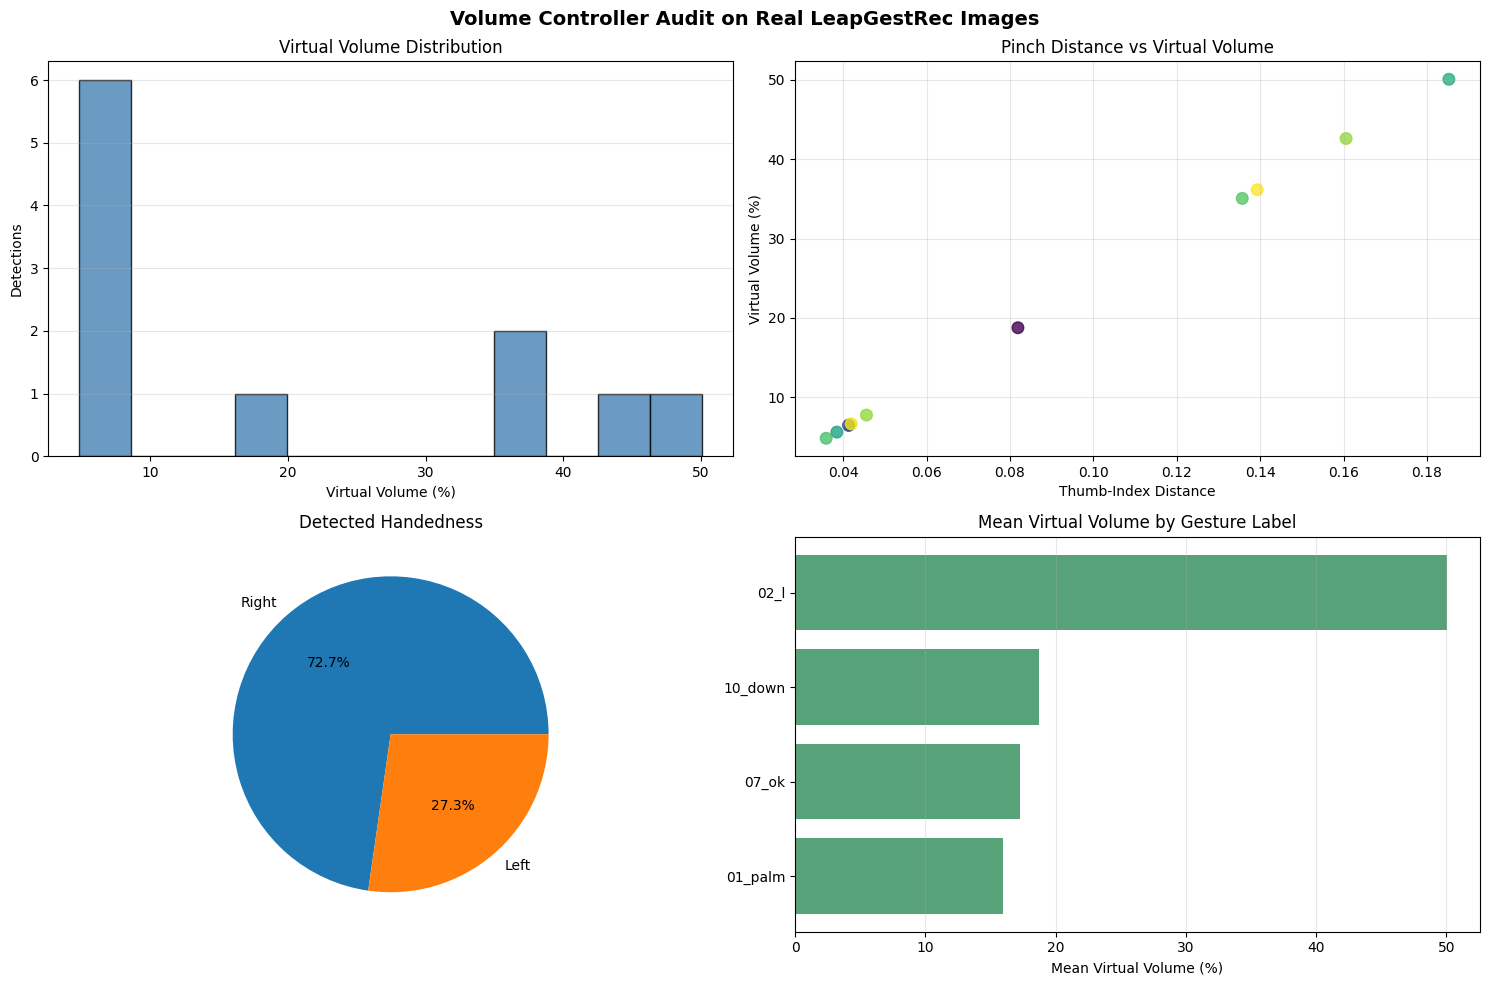

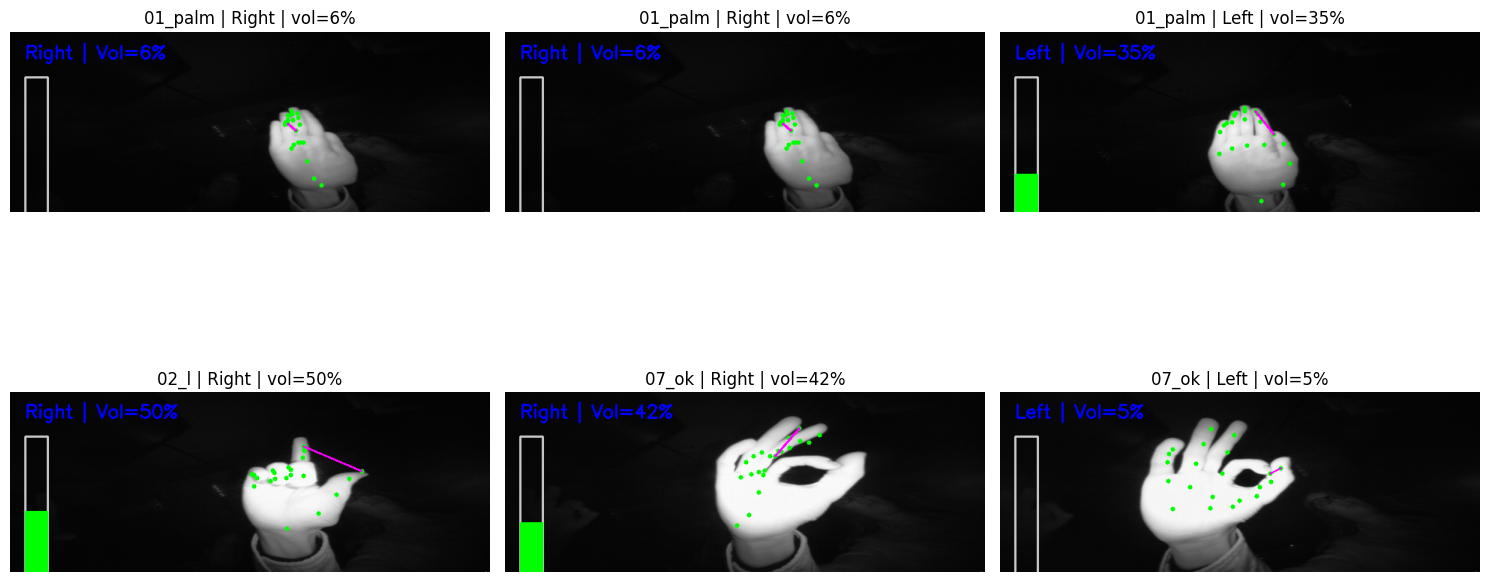

✓ Analysis plot saved to C:\Users\ahmad\volume_controller_project\outputs\volume_controller_analysis.png
✓ Preview plot saved to C:\Users\ahmad\volume_controller_project\outputs\volume_controller_previews.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Volume Controller Audit on Real LeapGestRec Images', fontsize=14, fontweight='bold')

axes[0, 0].hist(results_df['virtual_volume_percent'], bins=12, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Virtual Volume Distribution')
axes[0, 0].set_xlabel('Virtual Volume (%)')
axes[0, 0].set_ylabel('Detections')
axes[0, 0].grid(alpha=0.3, axis='y')

axes[0, 1].scatter(results_df['signal_distance'], results_df['virtual_volume_percent'], c=results_df['hand_size'], cmap='viridis', s=70, alpha=0.8)
axes[0, 1].set_title('Pinch Distance vs Virtual Volume')
axes[0, 1].set_xlabel('Thumb-Index Distance')
axes[0, 1].set_ylabel('Virtual Volume (%)')
axes[0, 1].grid(alpha=0.3)

handedness_counts = results_df['handedness'].value_counts()
axes[1, 0].pie(handedness_counts.values, labels=handedness_counts.index, autopct='%1.1f%%')
axes[1, 0].set_title('Detected Handedness')

label_plot = label_summary.head(8).sort_values('mean')
axes[1, 1].barh(label_plot.index.astype(str), label_plot['mean'], color='seagreen', alpha=0.8)
axes[1, 1].set_title('Mean Virtual Volume by Gesture Label')
axes[1, 1].set_xlabel('Mean Virtual Volume (%)')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
analysis_plot_path = OUTPUT_DIR / 'volume_controller_analysis.png'
plt.savefig(analysis_plot_path, dpi=120, bbox_inches='tight')
plt.show()

preview_plot_path = OUTPUT_DIR / 'volume_controller_previews.png'
if preview_records:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()
    for axis, preview_record in zip(axes, preview_records):
        axis.imshow(preview_record['image_rgb'])
        axis.set_title(preview_record['caption'])
        axis.axis('off')
    for axis in axes[len(preview_records):]:
        axis.axis('off')
    plt.tight_layout()
    plt.savefig(preview_plot_path, dpi=120, bbox_inches='tight')
    plt.show()
else:
    preview_plot_path = None

print(f'✓ Analysis plot saved to {analysis_plot_path}')
if preview_plot_path:
    print(f'✓ Preview plot saved to {preview_plot_path}')

## Save Results

Persist the real detection table, metrics, and project manifest to disk.

In [9]:
results_csv_path = OUTPUT_DIR / 'volume_controller_results.csv'
results_df.to_csv(results_csv_path, index=False)

metrics = {
    'project': 'Project 21 - Volume Controller',
    'model': 'MediaPipe Hand Landmarker',
    'task_family': 'hand landmarks + control logic',
    'dataset': {
        'name': 'LeapGestRec',
        'source': 'https://www.kaggle.com/datasets/gti-upm/leapgestrecog',
        'root': str(DATASET_DIR),
        'participants_found': len(participant_ids),
        'labels_found': int(len(label_counts)),
        'images_found': int(len(image_paths)),
        'official_split': 'none provided by source'
    },
    'evaluation': {
        'sampled_images': int(len(sample_paths)),
        'images_with_hand_detection': int(images_with_hands),
        'detection_coverage_percent': round(float(detection_coverage), 4),
        'control_signals_recorded': int(len(results_df)),
        'avg_virtual_volume_percent': round(float(results_df['virtual_volume_percent'].mean()), 4),
        'avg_signal_distance': round(float(results_df['signal_distance'].mean()), 6),
        'avg_hand_size': round(float(results_df['hand_size'].mean()), 6),
        'handedness_distribution': {str(key): int(value) for key, value in results_df['handedness'].value_counts(dropna=False).items()}
    },
    'qualitative_note': 'This notebook audits a virtual volume signal on image data. It does not claim real system volume control performance on a live webcam stream.'
}

metrics_path = OUTPUT_DIR / 'metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

manifest = {
    'project': 'Project 21 - Volume Controller',
    'preferred_stack': 'MediaPipe Hand Landmarker',
    'artifacts': {
        'results_csv': str(results_csv_path),
        'metrics_json': str(metrics_path),
        'analysis_plot': str(analysis_plot_path),
        'preview_plot': str(preview_plot_path) if preview_plot_path else None
    }
}

manifest_path = OUTPUT_DIR / 'project_manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print(f'✓ Results table saved to {results_csv_path}')
print(f'✓ Metrics saved to {metrics_path}')
print(f'✓ Manifest saved to {manifest_path}')

✓ Results table saved to C:\Users\ahmad\volume_controller_project\outputs\volume_controller_results.csv
✓ Metrics saved to C:\Users\ahmad\volume_controller_project\outputs\metrics.json
✓ Manifest saved to C:\Users\ahmad\volume_controller_project\outputs\project_manifest.json


## Limitations and Next Steps

**What this notebook does honestly:**
- downloads the real dataset in notebook code cells
- verifies labels, participant folders, and split limitations
- runs real MediaPipe hand landmark inference
- saves only real plots and artifact files produced by the run

**What it does not claim:**
- it does not claim real OS volume control latency or user experience on an image dataset
- it does not modify the machine audio state during notebook execution
- it does not fake a live webcam benchmark

**Natural next upgrades:**
- evaluate the same logic on a real webcam or hand-video benchmark
- add smoothing so the virtual volume signal is less jittery over time
- connect the virtual signal to a platform-specific audio backend only after separate live validation